 # **Fakenew Detection**

In [43]:
pip install pandas numpy scikit-learn nltk joblib streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Import Libraries

In [66]:
import pandas as pd
import numpy as np
import re
import string
import joblib
%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [67]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [68]:
fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [69]:
true

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [70]:
fake["label"] = 0
true["label"] = 1

In [71]:
data = pd.concat([fake, true])

data = data.sample(frac=1, random_state=42)

data.reset_index(drop=True, inplace=True)

In [72]:
data

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0


# Text Cleaning

In [73]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\[.*?\]', '', text)

    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    text = re.sub(r'<.*?>+', '', text)

    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    text = re.sub(r'\n', '', text)

    text = re.sub(r'\w*\d\w*', '', text)

    return text

In [74]:
data["text"] = data["text"].apply(clean_text)

In [75]:
data

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,century wire says ben stein reputable profess...,US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,washington reuters us president donald trump ...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,reuters puerto rico governor ricardo rossello...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,on monday donald trump once again embarrassed ...,News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,glasgow scotland reuters most us presidential...,politicsNews,"June 24, 2016",1
...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0
44894,PM May seeks to ease Japan's Brexit fears duri...,londontokyo reuters british prime minister th...,worldnews,"August 29, 2017",1
44895,Merkel: Difficult German coalition talks can r...,berlin reuters chancellor angela merkel said ...,worldnews,"November 16, 2017",1
44896,Trump Stole An Idea From North Korean Propaga...,jesus fcking christ our president is a moron n...,News,"July 14, 2017",0


In [76]:
X = data["text"]

y = data["label"]

# Train-Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7
)

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [79]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

# Predictions

In [80]:
pred = model.predict(X_test)

In [81]:
joblib.dump(model, "model.pkl")

joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

In [82]:
def predict_news(news):

    news = clean_text(news)

    news = vectorizer.transform([news])

    prediction = model.predict(news)

    if prediction[0] == 1:
        return "Real News"

    return "Fake News"

# **Logistic Regression**

In [101]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1 Score :", f1_score(y_test, pred_lr))

LOGISTIC REGRESSION RESULTS
---------------------------
Accuracy : 0.9812917594654789
Precision: 0.9776432231020028
Recall   : 0.9831381733021077
F1 Score : 0.9803829985987856


# **Random Forest**

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1 Score :", f1_score(y_test, pred_rf))

Random Forest Results
----------------------
Accuracy : 0.9842984409799554
Precision: 0.9829239766081871
Recall   : 0.9840749414519906
F1 Score : 0.983499122293739


# Confusion Matrix for Random Forest

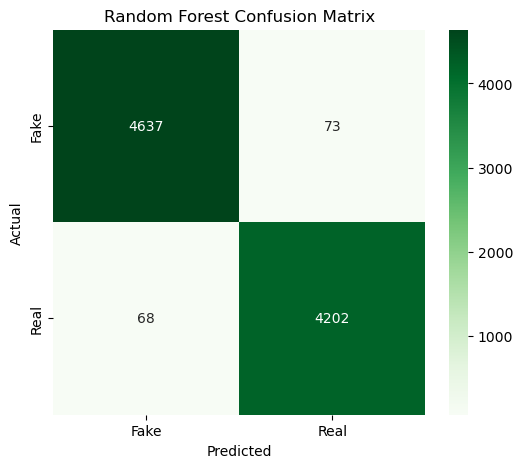

In [98]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# **Decision Tree**

In [95]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Results")
print("-----------------------")
print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt))
print("Recall   :", recall_score(y_test, pred_dt))
print("F1 Score :", f1_score(y_test, pred_dt))

Decision Tree Results
-----------------------
Accuracy : 0.9952115812917595
Precision: 0.995777621393385
Recall   : 0.9941451990632318
F1 Score : 0.9949607406539318


# Confusion Matrix for Decision Tree Model

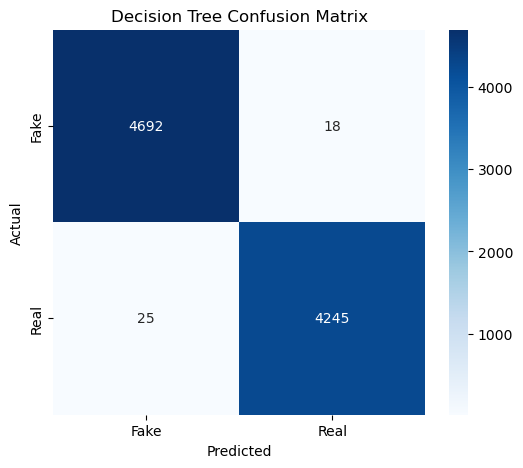

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# 1. Distribution of Real vs Fake News

This shows whether the dataset is balanced.

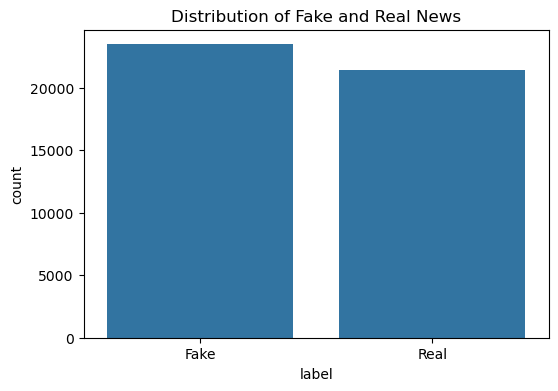

In [85]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data)

plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Distribution of Fake and Real News')

plt.savefig('distribution.png')

plt.show()

# **2.News Article Length Distribution**
Compare article lengths between fake and real news.

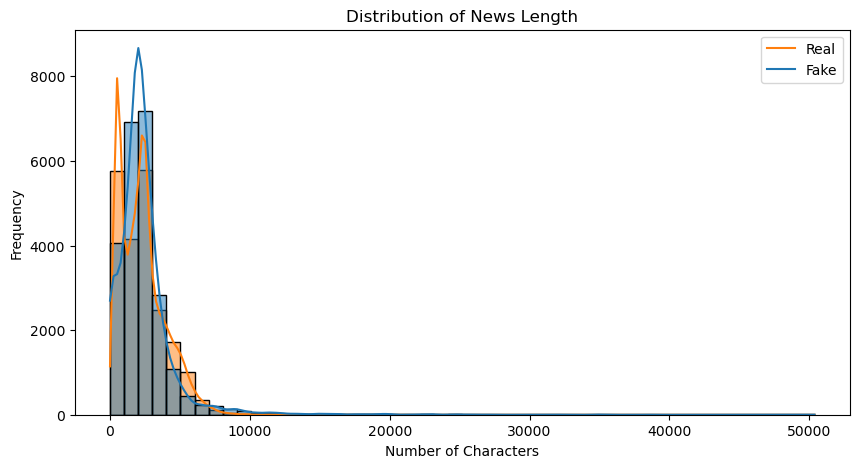

In [86]:
data['text_length'] = data['text'].apply(len)

plt.figure(figsize=(10, 5))

sns.histplot(
    data=data,
    x='text_length',
    hue='label',
    bins=50,
    kde=True
)

plt.legend(['Real', 'Fake'])
plt.title('Distribution of News Length')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

# 3. Top 20 Most Frequent Words in Fake News

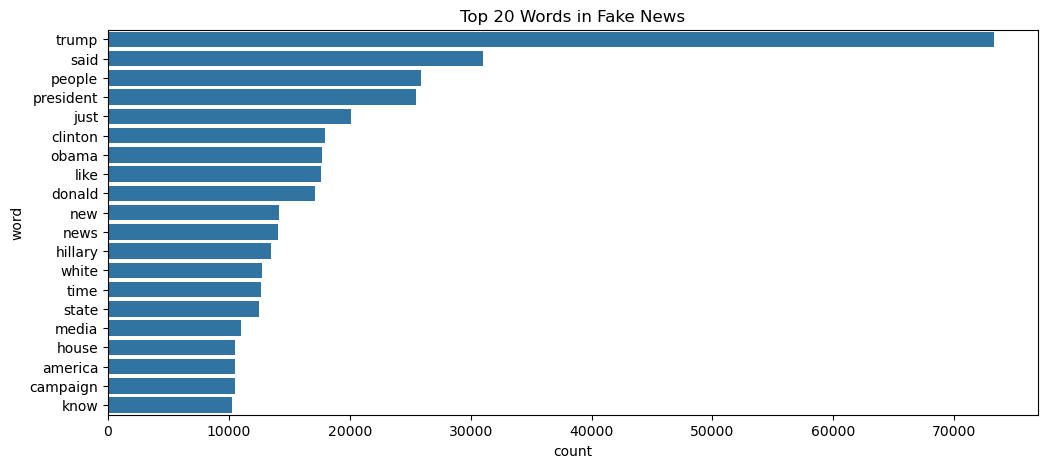

In [93]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

fake_text = " ".join(data[data['label'] == 0]['text'])

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform([fake_text])

freq = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
})

freq = freq.sort_values('count', ascending=False)

plt.figure(figsize=(12, 5))

sns.barplot(data=freq, x='count', y='word')

plt.title('Top 20 Words in Fake News')

plt.show()

# 5. Confusion Matrix

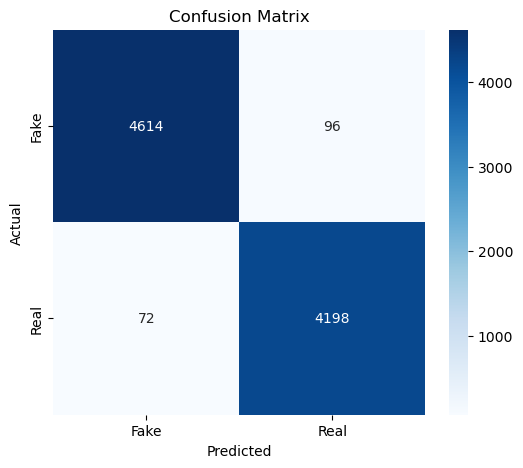

In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Model Comparison Table

In [102]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ],

    'Precision': [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf)
    ],

    'Recall': [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.981292,0.977643,0.983138,0.980383
1,Decision Tree,0.995212,0.995778,0.994145,0.994961
2,Random Forest,0.984298,0.982924,0.984075,0.983499
